# Reading CHELSA data

In [1]:
import xarray as xr

In [2]:
chelsa_cube = xr.open_datatree("out/techDemo_cube/techDemo.nc")
chelsa_cube

<xarray.DataTree>
Group: /
├── Group: /static
│   ├── Group: /static/chelsa_clim_ref_period
│   │       Dimensions:           (lat: 94, long: 154)
│   │       Coordinates:
│   │         * lat               (lat) float64 752B 51.45 51.44 51.43 ... 50.69 50.68 50.68
│   │         * long              (long) float64 1kB 3.514 3.523 3.531 ... 4.773 4.781 4.789
│   │       Data variables: (12/76)
│   │           ai                (lat, long) float32 58kB ...
│   │           bio10             (lat, long) uint16 29kB ...
│   │           bio11             (lat, long) uint16 29kB ...
│   │           bio12             (lat, long) uint16 29kB ...
│   │           bio13             (lat, long) uint16 29kB ...
│   │           bio14             (lat, long) uint16 29kB ...
│   │           ...                ...
│   │           swb               (lat, long) int16 29kB ...
│   │           swe               (lat, long) uint16 29kB ...
│   │           vpd_max           (lat, long) uint16 29kB ...
│   │           vpd_mean          (lat, long) uint16 29kB ...
│   │           vpd_min           (lat, long) uint16 29kB ...
│   │           vpd_range         (lat, long) uint16 29kB ...
│   ├── Group: /static/chelsa_clim_ref_month
│   │       Dimensions:  (months: 12, lat: 94, long: 154)
│   │       Coordinates:
│   │         * months   (months) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
│   │         * lat      (lat) float64 752B 51.45 51.44 51.43 51.43 ... 50.69 50.68 50.68
│   │         * long     (long) float64 1kB 3.514 3.523 3.531 3.539 ... 4.773 4.781 4.789
│   │       Data variables:
│   │           clt      (months, lat, long) float64 1MB ...
│   │           cmi      (months, lat, long) int16 347kB ...
│   │           hurs     (months, lat, long) uint16 347kB ...
│   │           pet      (months, lat, long) uint16 347kB ...
│   │           pr       (months, lat, long) uint16 347kB ...
│   │           rsds     (months, lat, long) uint16 347kB ...
│   │           sfcWind  (months, lat, long) uint16 347kB ...
│   │           tas      (months, lat, long) uint16 347kB ...
│   │           tasmax   (months, lat, long) uint16 347kB ...
│   │           tasmin   (months, lat, long) uint16 347kB ...
│   │           vpd      (months, lat, long) uint16 347kB ...
│   ├── Group: /static/chelsa_clim_sim_period
│   │       Dimensions:          (year_range: 3, model_name: 5, ensemble_member: 3,
│   │                             lat: 94, long: 154)
│   │       Coordinates:
│   │         * year_range       (year_range) <U9 108B '2011-2040' '2041-2070' '2071-2100'
│   │         * model_name       (model_name) <U13 260B 'gfdl-esm4' ... 'ukesm1-0-ll'
│   │         * ensemble_member  (ensemble_member) <U6 72B 'ssp126' 'ssp370' 'ssp585'
│   │         * lat              (lat) float64 752B 51.45 51.44 51.43 ... 50.69 50.68 50.68
│   │         * long             (long) float64 1kB 3.514 3.523 3.531 ... 4.773 4.781 4.789
│   │       Data variables: (12/46)
│   │           bio10            (year_range, model_name, ensemble_member, lat, long) uint16 1MB ...
│   │           bio11            (year_range, model_name, ensemble_member, lat, long) uint16 1MB ...
│   │           bio12            (year_range, model_name, ensemble_member, lat, long) uint16 1MB ...
│   │           bio13            (year_range, model_name, ensemble_member, lat, long) uint16 1MB ...
│   │           bio14            (year_range, model_name, ensemble_member, lat, long) uint16 1MB ...
│   │           bio15            (year_range, model_name, ensemble_member, lat, long) uint16 1MB ...
│   │           ...               ...
│   │           ngd0             (year_range, model_name, ensemble_member, lat, long) uint16 1MB ...
│   │           ngd10            (year_range, model_name, ensemble_member, lat, long) uint16 1MB ...
│   │           ngd5             (year_range, model_name, ensemble_member, lat, long) uint16 1MB ...
│   │           npp              (year_range, model_name, ensemble_member, lat, long) uint16 1MB 

In [3]:
ds = chelsa_cube["dynamic"]["chelsa_month"].dataset.copy(deep=True)
#CHELSA datacube is missing the CRS associated with the data
ds.rio.write_crs("EPSG:4326", inplace=True)
ds = ds.rename({'long': 'lon'})
ds

<xarray.Dataset> Size: 6MB
Dimensions:      (time: 12, lat: 94, lon: 154)
Coordinates:
  * time         (time) datetime64[ns] 96B 2018-01-01 2018-02-01 ... 2018-12-01
  * lat          (lat) float64 752B 51.45 51.44 51.43 ... 50.69 50.68 50.68
  * lon          (lon) float64 1kB 3.514 3.523 3.531 3.539 ... 4.773 4.781 4.789
    spatial_ref  int64 8B 0
Data variables:
    clt          (time, lat, lon) float64 1MB ...
    cmi          (time, lat, lon) int16 347kB ...
    hurs         (time, lat, lon) uint16 347kB ...
    pet          (time, lat, lon) uint16 347kB ...
    pr           (time, lat, lon) int32 695kB ...
    rsds         (time, lat, lon) uint16 347kB ...
    sfcWind      (time, lat, lon) uint16 347kB ...
    tas          (time, lat, lon) int32 695kB ...
    tasmax       (time, lat, lon) int32 695kB ...
    tasmin       (time, lat, lon) int32 695kB ...
    vpd          (time, lat, lon) uint16 347kB ...

# GBIF data

In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("out/gbif/gridded/0006956-260129131611470.csv", sep="\t")
df.head()

,month,year,specieskey,countrycode,occurrences,distinctobservers,eeacellcode
0,4,2018,2889173,BE,2,0,1kmE3867N3108
1,6,2020,2889173,BE,1,0,1kmE3917N3100
2,7,2018,2889173,BE,1,0,1kmE3949N3104
3,5,2020,2889173,BE,1,0,1kmE3919N3151
4,6,2020,2889173,BE,2,1,1kmE3928N3122


(array([2.191e+03, 3.610e+02, 9.500e+01, 4.300e+01, 2.200e+01, 1.400e+01,
        1.000e+01, 5.000e+00, 8.000e+00, 5.000e+00, 4.000e+00, 3.000e+00,
        2.000e+00, 4.000e+00, 4.000e+00, 3.000e+00, 1.000e+00, 3.000e+00,
        1.000e+00, 2.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 3.000e+00, 2.000e+00, 1.000e+00, 2.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00]),
 array([1.000e+00, 2.000e+00, 3.000e+00, 4.000e+00, 5.000e+00, 6.000e+00,
        7.000e+00, 8.000e+00, 9.000e+00, 1.000e+01, 1.100e+01, 1.200e+01,
        1.300e+01, 1.400e+01, 1.500e+01, 1.800e+01, 1.900e+01, 2.000e+01,
        2.200e+01, 2.500e+01, 2.600e+01, 2.800e+01, 2.900e+01, 3.000e+01,
      

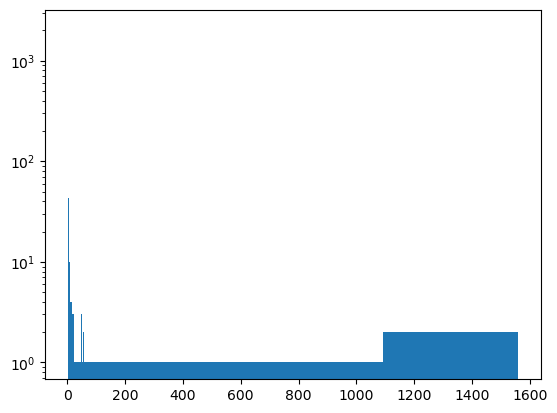

In [14]:
import numpy as np
plt.hist(df["occurrences"].values, bins=np.unique(df["occurrences"].values), log=True)

## Extracting EEA cell codes and constructing geometries

In order to compute zonal statistics for each EEA grid cell we need to extract the coordinates from the grid cell and subsequently construct a grid cell polygon which will be used in the zonal aggregation. The EEA grid is described in E (easting) and N (northing) coordinates that describe the bottom left corner of the cell. In addition the cell codes contain the resolution that was used in the construction of the grid cell

In [15]:
from shapely.geometry import box
import re

# 2. Define a function to create Square Polygons from the code
def parse_to_polygon(code):
    """
    Use a cell code to construct a geospatial polygon. The function dynamically scrapes the E and N coordinates + resolution 
    and constructs the corresponding bounding box
    """
    # ^ matches the start of the string
    # (\d+) a series of digits
    # (km|m) a substring matching either km or m
    match = re.match(r'^(\d+)(km|m)E(\d+)N(\d+)$', code)
    if not match:
        raise ValueError(f"Invalid EEA grid code format: {code}")
      
    res_val, res_unit, easting_code, northing_code = match.groups()
    #Convert resolution to meters
    cell_size_m = int(res_val) * 1000 if res_unit == 'km' else int(res_val)

    # Coordinate are 7 digits and trailing zeros are removed from the cell code to make them more compact
    # Calculate the multiplier based on trailing zeros
    # Convert cell size to string, strip non-zeros, and count difference
    str_size = str(cell_size_m)
    trailing_zeros = len(str_size) - len(str_size.rstrip('0'))
    multiplier = 10 ** trailing_zeros
        
    # 4. Calculate Lower-Left coordinates
    ll_easting = int(easting_code) * multiplier
    ll_northing = int(northing_code) * multiplier
    ur_easting = ll_easting + cell_size_m
    ur_northing = ll_northing + cell_size_m
    (ll_easting, ll_northing, ur_easting, ur_northing)
    
    return box(ll_easting, ll_northing, ur_easting, ur_northing)

In [10]:
test_cellcodes=["100kmE51N29", "50kmE510N290","10kmE510N293",
                "5kmE5105N2930","2kmE5104N2932","1kmE5105N2933",
                "250mE510500N293350","100mE51052N29336","25mE5105200N2933675"]

test_polygons = [parse_to_polygon(code) for code in test_cellcodes]

test_polygons

[<POLYGON ((5200000 2900000, 5200000 3000000, 5100000 3000000, 5100000 290000...>,
 <POLYGON ((5150000 2900000, 5150000 2950000, 5100000 2950000, 5100000 290000...>,
 <POLYGON ((5110000 2930000, 5110000 2940000, 5100000 2940000, 5100000 293000...>,
 <POLYGON ((5110000 2930000, 5110000 2935000, 5105000 2935000, 5105000 293000...>,
 <POLYGON ((5106000 2932000, 5106000 2934000, 5104000 2934000, 5104000 293200...>,
 <POLYGON ((5106000 2933000, 5106000 2934000, 5105000 2934000, 5105000 293300...>,
 <POLYGON ((5105250 2933500, 5105250 2933750, 5105000 2933750, 5105000 293350...>,
 <POLYGON ((5105300 2933600, 5105300 2933700, 5105200 2933700, 5105200 293360...>,
 <POLYGON ((5105225 2933675, 5105225 2933700, 5105200 2933700, 5105200 293367...>]

In [21]:
resolutions = [100000, 50000, 10000, 5000, 2000, 1000, 250, 100, 25]
for poly, res in zip(test_polygons, resolutions):
    assert (poly.bounds[2]-poly.bounds[0])==res, f"Easting coordinates do not match for resolution {res}, calculated resolution is {poly.bounds[2]-poly.bounds[0]}"
    assert (poly.bounds[3]-poly.bounds[1])==res, f"Northing coordinates do not match for resolution {res}, calculated resolution is {poly.bounds[3]-poly.bounds[2]}"

In [18]:
import geopandas as gpd
df["geometry"] = df["eeacellcode"].apply(parse_to_polygon)
gbif_gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:3035")
gbif_gdf.head()

,month,year,specieskey,countrycode,occurrences,distinctobservers,eeacellcode,geometry
0,4,2018,2889173,BE,2,0,1kmE3867N3108,"POLYGON ((3868000 3108000, 3868000 3109000, 38..."
1,6,2020,2889173,BE,1,0,1kmE3917N3100,"POLYGON ((3918000 3100000, 3918000 3101000, 39..."
2,7,2018,2889173,BE,1,0,1kmE3949N3104,"POLYGON ((3950000 3104000, 3950000 3105000, 39..."
3,5,2020,2889173,BE,1,0,1kmE3919N3151,"POLYGON ((3920000 3151000, 3920000 3152000, 39..."
4,6,2020,2889173,BE,2,1,1kmE3928N3122,"POLYGON ((3929000 3122000, 3929000 3123000, 39..."


In [17]:
!pip install mapclassify

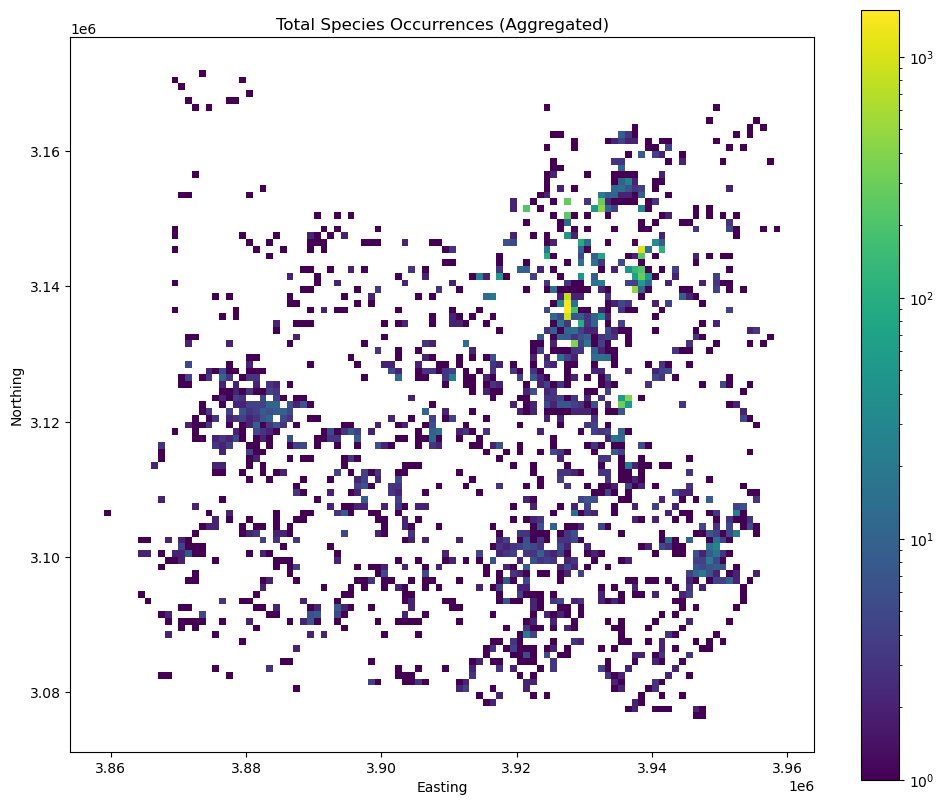

In [20]:
import matplotlib.colors as colors

gdf_total = gbif_gdf.dissolve(
    by='eeacellcode', 
    aggfunc={'occurrences': 'sum'}
).reset_index()

# 2. VISUALIZE THE TOTALS
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the aggregated grid cells
gdf_total.plot(
    column='occurrences',
    cmap='viridis',
    legend=True,
    # Adding a LogNorm scale here so cells with 1 observation aren't 
    # visually swallowed by cells with 1,000+ observations
    norm=colors.LogNorm(vmin=1, vmax=gdf_total['occurrences'].max()),
    edgecolors='none', # Turn off borders if grid cells are too dense
    ax=ax
)

plt.title("Total Species Occurrences (Aggregated)")
plt.xlabel("Easting")
plt.ylabel("Northing")

plt.show()

## Zonal statistics

In [21]:
import regionmask
import geopandas as gpd
import pandas as pd
import os

def ds_zonal_statistics_table(gbif_df, env_ds, out_name, out_path="", cellcode_colname="eeacellcode"):
    """
    Function that ingests a environmental xarray Dataset and computes the zonal average associated with the
    EEA cell defined within a GBIF dataframe.

    Args:
        param gbif_df (pd.Dataframe): A GBIF data table that was generated using the SQL cubing functionality. The data table contains EEA cells
        param env_ds (xarray.Dataset): A xarray dataset that contains environmental data. The xarray dataset must have a CRS associated with it
        param out_name (str): The output name of the zonal average table for the sampled EEA cells

    Returns:
        env_df (pd.Dataframe): A data frame containing the zonal averages for each of the EEA cells for the different timesteps
    """
    # Built in check to assure that environmental dataset has a CRS to which the polygons can be projected
    assert env_ds.rio.crs!=None, "The environmental Dataset does not have a CRS in its metadata"

    # Apply the parse polygon function to the eeacellcode column to generate a geometry column
    gbif_df['geometry'] = df['eeacellcode'].apply(parse_to_polygon)

    # Convert dataframe to geopandas dataframe. We explicitly define the CRS as EPSG:3035 (ETRS89-LAEA=EEA grid)
    gbif_gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:3035")

    #Convert geometry coordinates to CRS of the xarray dataset
    gbif_gdf = gbif_gdf.to_crs(env_ds.rio.crs)

    # Retrieve all the unique eeacell codes from the geodataframe and reset the index, i.e. reset the pandas index
    unique_eea = gbif_gdf.drop_duplicates(subset='eeacellcode').reset_index(drop=True)

    # Generate regions that correspond to the EEA cells
    # Region mask requires a geodataframe that contains polygons and is indexed based on the cell code columnest
    regions = regionmask.from_geopandas(unique_eea,names="eeacellcode")

    # Mask out all the values that fall into the defined regions in the region from the original xr Dataset
    mask = regions.mask(ds).rename("region")

    # Group values based on region indices and aggregate them as a mean
    env_stats = env_ds.groupby(mask).mean()

    # Convert the region ids to integers
    valid_ids = env_stats['region'].values.astype(int)
    
    # Map the region IDs to the corresponding EEA cell codes
    original_codes = regions[valid_ids].names
    
    # Transform the region coordinate to the EEA cell codes
    env_stats = env_stats.assign_coords(region=original_codes)
    env_stats = env_stats.rename({'region': 'eeacellcode'})
    
    # Export the EO/climate dataset to a pandas data frame (tabular format conversion)
    env_df = env_stats.to_dataframe().reset_index()
    env_df.to_csv(os.path.join(out_path, out_name), sep=",")
    
    return env_df

In [42]:
os.path.join("test.csv", "")

'test.csv\\'

In [22]:
test = ds_zonal_statistics_table(df, ds, "test.csv")
test.head()

,eeacellcode,time,clt,cmi,hurs,pet,pr,rsds,sfcWind,tas,tasmax,tasmin,vpd,spatial_ref
0,1kmE3867N3108,2018-01-01,5387.333607,481.5,6911.0,2981.5,7798.5,2728.0,5494.5,2792.0,2815.0,2764.0,2896.0,0
1,1kmE3867N3108,2018-02-01,2997.777857,0.0,6087.0,2969.0,2967.5,7322.5,4841.5,2744.0,2776.0,2716.5,2617.0,0
2,1kmE3867N3108,2018-03-01,5323.444519,358.0,6363.5,4660.0,8239.0,8080.0,4657.0,2784.5,2822.0,2751.0,3237.0,0
3,1kmE3867N3108,2018-04-01,4248.166668,-359.0,5997.5,9072.5,5480.0,15734.5,4094.0,2854.5,2900.0,2804.0,5715.0,0
4,1kmE3867N3108,2018-05-01,3381.555633,-727.0,6010.0,12663.0,5395.0,20918.0,3418.0,2887.0,2938.0,2835.5,7033.5,0


In [23]:
test["geometry"]=test["eeacellcode"].apply(parse_to_polygon)
test_gdf = gpd.GeoDataFrame(test, geometry="geometry", crs="EPSG:3035")
test_gdf

,eeacellcode,time,clt,cmi,hurs,pet,pr,rsds,sfcWind,tas,tasmax,tasmin,vpd,spatial_ref,geometry
0,1kmE3867N3108,2018-01-01,5387.333607,481.5,6911.0,2981.5,7798.5,2728.0,5494.5,2792.0,2815.0,2764.0,2896.0,0,"POLYGON ((3868000 3108000, 3868000 3109000, 38..."
1,1kmE3867N3108,2018-02-01,2997.777857,0.0,6087.0,2969.0,2967.5,7322.5,4841.5,2744.0,2776.0,2716.5,2617.0,0,"POLYGON ((3868000 3108000, 3868000 3109000, 38..."
2,1kmE3867N3108,2018-03-01,5323.444519,358.0,6363.5,4660.0,8239.0,8080.0,4657.0,2784.5,2822.0,2751.0,3237.0,0,"POLYGON ((3868000 3108000, 3868000 3109000, 38..."
3,1kmE3867N3108,2018-04-01,4248.166668,-359.0,5997.5,9072.5,5480.0,15734.5,4094.0,2854.5,2900.0,2804.0,5715.0,0,"POLYGON ((3868000 3108000, 3868000 3109000, 38..."
4,1kmE3867N3108,2018-05-01,3381.555633,-727.0,6010.0,12663.0,5395.0,20918.0,3418.0,2887.0,2938.0,2835.5,7033.5,0,"POLYGON ((3868000 3108000, 3868000 3109000, 38..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19579,1kmE3911N3102,2018-08-01,3632.666415,-516.0,5868.0,11405.0,6246.5,16810.0,3113.5,2922.0,2969.5,2883.5,9086.0,0,"POLYGON ((3912000 3102000, 3912000 3103000, 39..."
19580,1kmE3911N3102,2018-09-01,3455.388910,-340.5,5859.0,7514.0,4111.0,12615.0,3189.0,2883.5,2930.0,2842.0,7138.0,0,"POLYGON ((3912000 3102000, 3912000 3103000, 39..."
19581,1kmE3911N3102,2018-10-01,3731.500055,-103.0,6142.0,5021.0,3989.0,8327.0,3459.0,2855.0,2900.0,2821.0,5527.0,0,"POLYGON ((3912000 3102000, 3912000 3103000, 39..."
19582,1kmE3911N3102,2018-11-01,4414.722164,176.5,6654.5,2357.5,4122.0,4238.0,3913.0,2804.5,2837.5,2782.5,3418.0,0,"POLYGON ((3912000 3102000, 3912000 3103000, 39..."


In [29]:
filtered_gdf = test_gdf[test_gdf["time"] == "2018-01-01"]
filtered_gdf.head()

,eeacellcode,time,clt,cmi,hurs,pet,pr,rsds,sfcWind,tas,tasmax,tasmin,vpd,spatial_ref,geometry
0,1kmE3867N3108,2018-01-01,5387.333607,481.500000,6911.0,2981.500000,7798.5,2728.000000,5494.5,2792.000000,2815.0,2764.0,2896.0,0,"POLYGON ((3868000 3108000, 3868000 3109000, 38..."
12,1kmE3917N3100,2018-01-01,5562.499926,573.000000,6975.0,2633.000000,8362.0,2774.000000,5063.0,2791.000000,2814.0,2765.0,2817.0,0,"POLYGON ((3918000 3100000, 3918000 3101000, 39..."
24,1kmE3949N3104,2018-01-01,5582.481458,299.666667,6765.0,2955.666667,5952.0,2710.666667,5177.0,2792.666667,2816.0,2768.0,3047.0,0,"POLYGON ((3950000 3104000, 3950000 3105000, 39..."
36,1kmE3919N3151,2018-01-01,5356.222324,547.000000,6877.0,3164.000000,8636.0,2612.000000,5822.0,2792.000000,2812.0,2768.0,2928.0,0,"POLYGON ((3920000 3151000, 3920000 3152000, 39..."
48,1kmE3928N3122,2018-01-01,5469.944633,547.500000,6842.0,2948.500000,8423.0,2710.500000,5298.5,2793.000000,2815.0,2767.0,2981.0,0,"POLYGON ((3929000 3122000, 3929000 3123000, 39..."


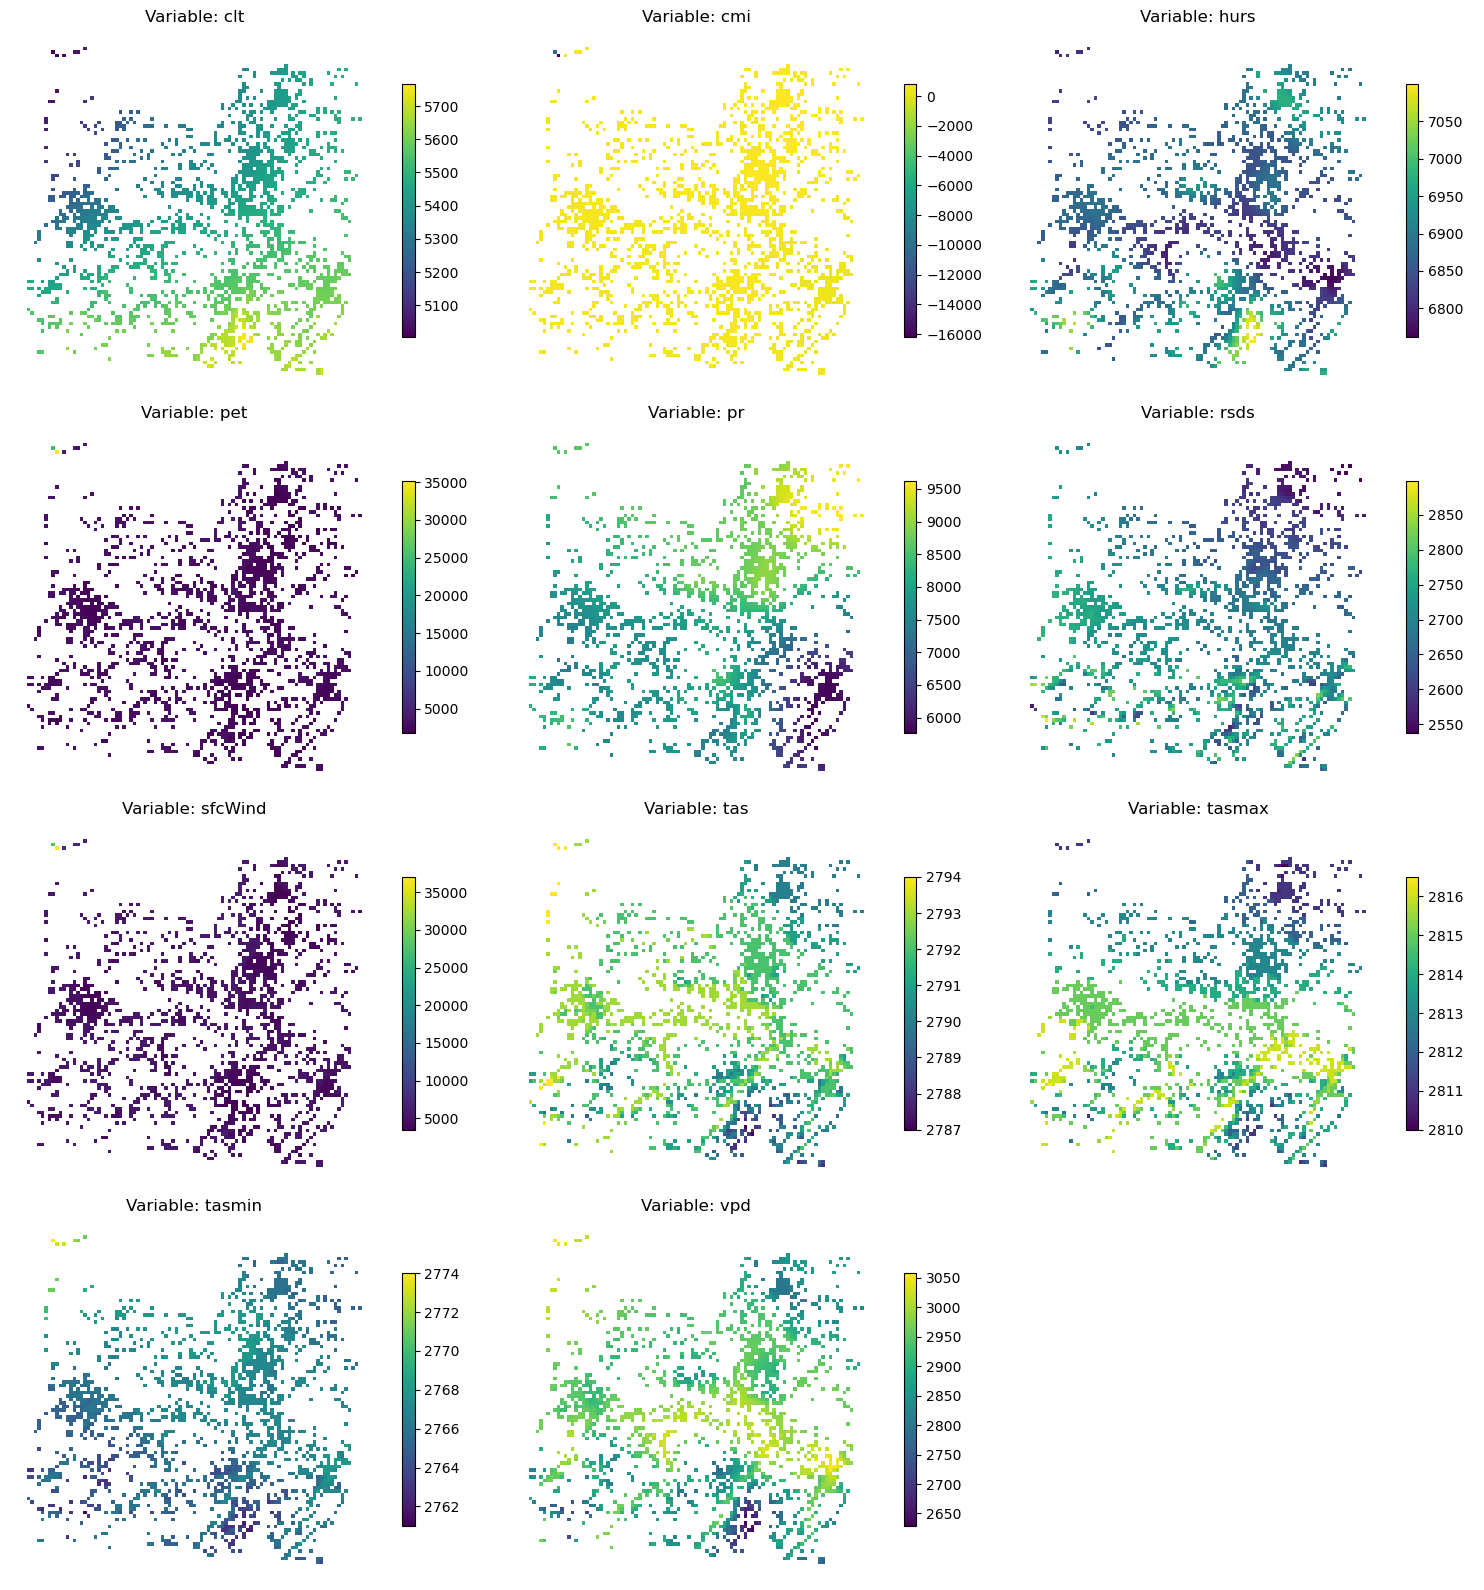

In [30]:
import matplotlib.pyplot as plt
import math

# 2. Identify the variables to plot
# We automatically exclude the metadata and geometry columns
exclude_cols = ['eeacellcode', 'time', 'spatial_ref', 'geometry']
variables = [col for col in filtered_gdf.columns if col not in exclude_cols]

# 3. Set up the subplot grid
n_vars = len(variables)
cols = 3  # Number of columns in our grid
rows = math.ceil(n_vars / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy looping

# 4. Loop through the variables and plot
for i, var in enumerate(variables):
    ax = axes[i]
    
    # Plot the specific variable
    filtered_gdf.plot(
        column=var, 
        ax=ax, 
        cmap='viridis', 
        legend=True,
        # Shrink the legend slightly to fit the grid better
        legend_kwds={'shrink': 0.7} 
    )
    
    ax.set_title(f"Variable: {var}")
    ax.set_axis_off() # Hide the axis ticks/coordinates for a cleaner look

# 5. Clean up any empty subplots
# If you have 11 variables but 12 subplots (3x4), this hides the 12th empty box
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [33]:
for branch in chelsa_cube:
    for ds in chelsa_cube[branch]:
        env_ds = chelsa_cube[branch][ds].dataset.copy(deep=True)
        #CHELSA datacube is missing the CRS associated with the data
        env_ds.rio.write_crs("EPSG:4326", inplace=True)
        env_ds = env_ds.rename({'long': 'lon'})

static
chelsa_clim_ref_period
chelsa_clim_ref_month
chelsa_clim_sim_period
chelsa_clim_sim_month
dynamic
chelsa_month


# Rasterize GBIF data

In [48]:
import pandas as pd
import geopandas as gpd
import xarray as xr
from geocube.api.core import make_geocube
import rioxarray

def rasterize_and_merge_gbif(gbif_df, env_ds, tolerance=2.0):
    """
    Converts a dataframe of GBIF occurrences to a raster aligned with an xarray dataset.
    Includes a strict check to ensure vector resolution <= raster resolution.
    """
    # Built in check to assure that environmental dataset has a CRS to which the polygons can be projected
    assert env_ds.rio.crs!=None, "The environmental Dataset does not have a CRS in its metadata"

    if {"lat","lon"}.issubset(env_ds.coords):
        env_ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    
    # Apply the parse polygon function to the eeacellcode column to generate a geometry column
    gbif_df['geometry'] = df['eeacellcode'].apply(parse_to_polygon)

    # Convert dataframe to geopandas dataframe. We explicitly define the CRS as EPSG:3035 (ETRS89-LAEA=EEA grid)
    gbif_gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:3035")

    # 2. Prepare the time column to match the xarray 'time' dimension
    if 'month' in gbif_gdf.columns and 'year' in gbif_gdf.columns:
        gbif_gdf['time'] = pd.to_datetime(gbif_gdf[['year', 'month']].assign(day=1))
    
    # ==========================================
    # 2. UNIVERSAL RESOLUTION CHECK (Square Meters)
    # ==========================================
    # We use EPSG:6933 (WGS 84 / NSIDC EASE-Grid 2.0 Global) 
    # It is a cylindrical equal-area projection, perfect for calculating true area globally.
    equal_area_crs = "EPSG:6933"
    
    # A. Get the median physical area of the GBIF polygons
    gdf_ea = gbif_gdf.to_crs(equal_area_crs)
    gbif_area_sqm = gdf_ea.geometry.area.median()
    
    # B. Extract a single pixel from the center of the target raster
    minx, miny, maxx, maxy = env_ds.rio.bounds()
    cx = (minx + maxx) / 2.0
    cy = (miny + maxy) / 2.0
    target_x_res, target_y_res = map(abs, env_ds.rio.resolution())
    
    # Create a Shapely box representing that center pixel
    pixel_geom = box(cx - target_x_res/2, cy - target_y_res/2, cx + target_x_res/2, cy + target_y_res/2)
    
    # Convert that pixel to a GeoDataFrame and calculate its physical area
    pixel_gdf = gpd.GeoDataFrame({'geometry': [pixel_geom]}, crs=env_ds.rio.crs)
    pixel_gdf_ea = pixel_gdf.to_crs(equal_area_crs)
    target_area_sqm = pixel_gdf_ea.geometry.area.iloc[0]
    
    # C. Compare the areas
    if gbif_area_sqm > (target_area_sqm * tolerance):
        raise ValueError(
            f"RESOLUTION MISMATCH ERROR:\n"
            f"Your GBIF geometries are significantly coarser than the target raster.\n"
            f" - Target Pixel Area: ~{target_area_sqm:,.0f} sq meters\n"
            f" - GBIF Cell Area:    ~{gbif_area_sqm:,.0f} sq meters\n"
            f"Please aggregate your environmental data to a coarser grid first."
        )
    else:
        print(f"Resolution check passed: Vector area (~{gbif_area_sqm:,.0f} sqm) is safely within Raster area (~{target_area_sqm:,.0f} sqm).")

    # ==========================================
    # 3. RASTERIZE AND ALIGN
    # ==========================================
    # Reproject the vector data to the target's native CRS right before rasterizing
    gbif_gdf = gbif_gdf.to_crs(env_ds.rio.crs)
    
    # Rasterize using GeoCube, strictly conforming to the target grid
    rasterized_ds = make_geocube(
        vector_data=gbif_gdf,
        measurements=['occurrences'], 
        like=env_ds, 
        group_by='time',
        fill=0
    )
    
    # Ensure the time dimensions perfectly match (filling empty GBIF months with 0)
    if 'time' in env_ds.dims and 'time' in rasterized_ds.dims:
        rasterized_ds = rasterized_ds.reindex(time=env_ds.time, fill_value=0)
    
    # Merge into the final dataset
    final_ds = env_ds.assign(occurrences=rasterized_ds['occurrences'])
    
    return final_ds

In [10]:
ds.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [49]:
test = rasterize_and_merge_gbif(df, ds)

Resolution check passed: Vector area (~1,000,000 sqm) is safely within Raster area (~541,576 sqm).


In [50]:
test

<xarray.Dataset> Size: 8MB
Dimensions:      (time: 12, lat: 94, lon: 154, y: 94, x: 154)
Coordinates:
  * time         (time) datetime64[ns] 96B 2018-01-01 2018-02-01 ... 2018-12-01
  * lat          (lat) float64 752B 51.45 51.44 51.43 ... 50.69 50.68 50.68
  * lon          (lon) float64 1kB 3.514 3.523 3.531 3.539 ... 4.773 4.781 4.789
    spatial_ref  int64 8B 0
  * y            (y) float64 752B 51.45 51.44 51.43 51.43 ... 50.69 50.68 50.68
  * x            (x) float64 1kB 3.514 3.523 3.531 3.539 ... 4.773 4.781 4.789
Data variables:
    clt          (time, lat, lon) float64 1MB ...
    cmi          (time, lat, lon) int16 347kB ...
    hurs         (time, lat, lon) uint16 347kB ...
    pet          (time, lat, lon) uint16 347kB ...
    pr           (time, lat, lon) int32 695kB ...
    rsds         (time, lat, lon) uint16 347kB ...
    sfcWind      (time, lat, lon) uint16 347kB ...
    tas          (time, lat, lon) int32 695kB ...
    tasmax       (time, lat, lon) int32 695kB ...
    tasmin       (time, lat, lon) int32 695kB ...
    vpd          (time, lat, lon) uint16 347kB ...
    occurrences  (time, y, x) int64 1MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0

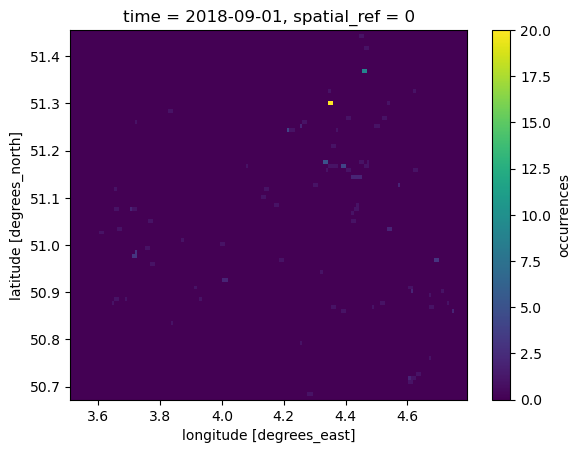

In [55]:
test["occurrences"].sel(time="2018-09-01").plot()

In [17]:
ds.rio.resolution()

MissingSpatialDimensionError: x dimension not found. 'rio.set_spatial_dims()' or using 'rename()' to change the dimension name to 'x' can address this.

In [32]:
list(ds.coords.keys())

['time', 'lat', 'lon', 'spatial_ref']

In [34]:
if {"lat", "lon"}.issubset(ds.coords):
    print(True)

True


In [56]:
import pandas as pd
import geopandas as gpd
import xarray as xr
from geocube.api.core import make_geocube
import rioxarray
from shapely.geometry import box
from pathlib import Path

def rasterize_and_save_species(df, target_ds, output_dir, file_format="netcdf", tolerance=2.0):
    """
    Converts a dataframe of multi-species GBIF occurrences into a raster grid
    and saves each species as an independent NetCDF or Zarr file.
    """
    # Create the output directory if it doesn't exist
    out_path = Path(output_dir)
    out_path.mkdir(parents=True, exist_ok=True)
    
    # ==========================================
    # 1. SETUP & ALIGN METADATA
    # ==========================================
    gdf = gpd.GeoDataFrame(df, geometry='geometry')
    
    if gdf.crs is None:
        gdf.set_crs("EPSG:3035", inplace=True)
        
    if {"lat", "lon"}.issubset(target_ds.coords):
        target_ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
        
    if target_ds.rio.crs is None:
        target_ds.rio.write_crs("EPSG:4326", inplace=True)

    if 'month' in gdf.columns and 'year' in gdf.columns:
        gdf['time'] = pd.to_datetime(gdf[['year', 'month']].assign(day=1))
    
    # ==========================================
    # 2. UNIVERSAL RESOLUTION CHECK 
    # ==========================================
    equal_area_crs = "EPSG:6933"
    
    gdf_ea = gdf.to_crs(equal_area_crs)
    gbif_area_sqm = gdf_ea.geometry.area.median()
    
    minx, miny, maxx, maxy = target_ds.rio.bounds()
    cx, cy = (minx + maxx) / 2.0, (miny + maxy) / 2.0
    target_x_res, target_y_res = map(abs, target_ds.rio.resolution())
    
    pixel_geom = box(cx - target_x_res/2, cy - target_y_res/2, cx + target_x_res/2, cy + target_y_res/2)
    pixel_gdf = gpd.GeoDataFrame({'geometry': [pixel_geom]}, crs=target_ds.rio.crs)
    target_area_sqm = pixel_gdf.to_crs(equal_area_crs).geometry.area.iloc[0]
    
    if gbif_area_sqm > (target_area_sqm * tolerance):
        raise ValueError(
            f"RESOLUTION MISMATCH ERROR: Vector area (~{gbif_area_sqm:,.0f} sqm) "
            f"exceeds Raster area (~{target_area_sqm:,.0f} sqm)."
        )

    # ==========================================
    # 3. RASTERIZE AND SAVE ITERATIVELY
    # ==========================================
    gdf = gdf.to_crs(target_ds.rio.crs)
    unique_species = gdf['specieskey'].unique()
    saved_files = []
    
    for species in unique_species:
        print(f"Processing speciesKey: {species}...")
        species_gdf = gdf[gdf['specieskey'] == species]
        
        species_raster = make_geocube(
            vector_data=species_gdf,
            measurements=['occurrences'], 
            like=target_ds, 
            group_by='time',
            fill=0
        )
        
        if 'time' in target_ds.dims:
            species_raster = species_raster.reindex(time=target_ds.time, fill_value=0)
            
        # Create a clean dataset just for this species
        species_ds = xr.Dataset(
            {"occurrences": species_raster['occurrences']},
            coords=target_ds.coords
        )
        
        # Save to disk
        if file_format.lower() == "zarr":
            file_name = out_path / f"species_{species}.zarr"
            species_ds.to_zarr(file_name, mode="w")
        else:
            file_name = out_path / f"species_{species}.nc"
            species_ds.to_netcdf(file_name)
            
        saved_files.append(file_name)
        
        # Close the dataset to free up memory before the next loop
        species_ds.close()

In [57]:
rasterize_and_save_species(df, ds, "test")

Processing speciesKey: 2889173...
Processing speciesKey: 1311477...


In [58]:
ls "test/"

 Volume in drive C is OS
 Volume Serial Number is 1C25-B250

 Directory of C:\Users\niels\Documents\Repositories\BmC\scripts\harmonization\test

18/02/2026  14:07    <DIR>          .
18/02/2026  14:07    <DIR>          ..
18/02/2026  14:07         1.411.483 species_1311477.nc
18/02/2026  14:07         1.411.483 species_2889173.nc
               2 File(s)      2.822.966 bytes
               2 Dir(s)  225.397.194.752 bytes free


In [74]:
test_gbif_ds = xr.open_dataset("test/species_2889173.nc", engine="netcdf4")

In [75]:
year_occ = test_gbif_ds.sum(dim='time')

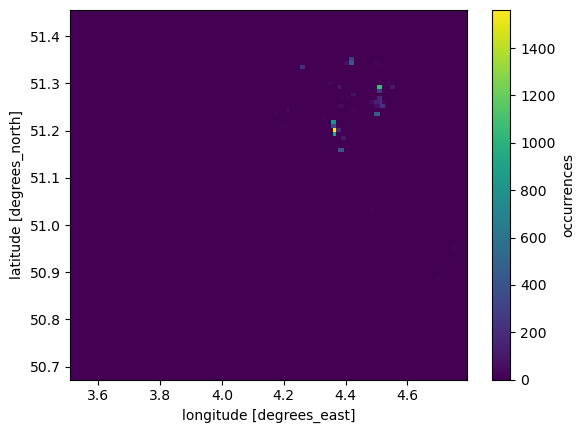

In [76]:
year_occ["occurrences"].plot()

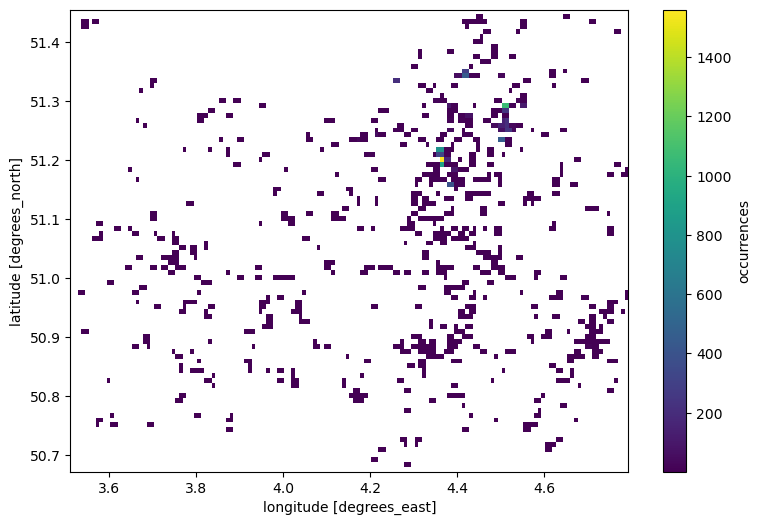

In [77]:
# 1. Mask the zeros (keep values only where > 0)
masked_map = year_occ["occurrences"].where(year_occ["occurrences"] > 0)

# 2. Plot using a nice sequential colormap (like 'viridis', 'plasma', or 'Reds')
masked_map.plot(cmap='viridis', size=6, aspect=1.5)

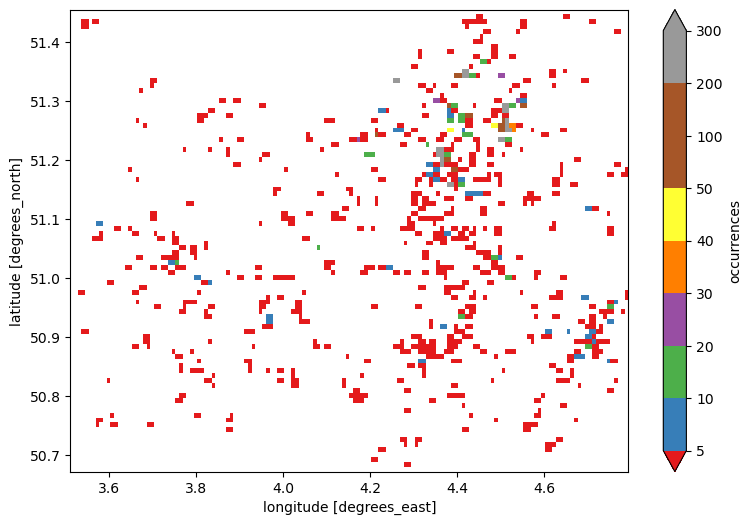

In [81]:
masked_map.plot(
    cmap='Set1', 
    levels=[5,10,20,30,40,50,100, 200, 300], 
    size=6, 
    aspect=1.5
)


In [83]:
df["occurrences"].sum()

np.int64(15010)

In [91]:
import numpy as np
np.sum(year_occ["occurrences"].values)

np.float64(16251.0)

In [95]:
df["occurrences"].sum()

np.int64(15010)

In [94]:
df

,month,year,specieskey,countrycode,occurrences,distinctobservers,eeacellcode,geometry
0,4,2018,2889173,BE,2,0,1kmE3867N3108,"POLYGON ((3868000 3108000, 3868000 3109000, 38..."
1,6,2020,2889173,BE,1,0,1kmE3917N3100,"POLYGON ((3918000 3100000, 3918000 3101000, 39..."
2,7,2018,2889173,BE,1,0,1kmE3949N3104,"POLYGON ((3950000 3104000, 3950000 3105000, 39..."
3,5,2020,2889173,BE,1,0,1kmE3919N3151,"POLYGON ((3920000 3151000, 3920000 3152000, 39..."
4,6,2020,2889173,BE,2,1,1kmE3928N3122,"POLYGON ((3929000 3122000, 3929000 3123000, 39..."
...,...,...,...,...,...,...,...,...
2817,3,2020,2889173,BE,1,0,1kmE3889N3106,"POLYGON ((3890000 3106000, 3890000 3107000, 38..."
2818,7,2019,2889173,BE,2,0,1kmE3911N3102,"POLYGON ((3912000 3102000, 3912000 3103000, 39..."
2819,3,2019,2889173,BE,1,0,1kmE3900N3116,"POLYGON ((3901000 3116000, 3901000 3117000, 39..."
2820,10,2020,1311477,BE,1,1,1kmE3941N3085,"POLYGON ((3942000 3085000, 3942000 3086000, 39..."


In [130]:
import pandas as pd
import geopandas as gpd
import xarray as xr
from geocube.api.core import make_geocube
from geocube.rasterize import rasterize_image
from rasterio.enums import MergeAlg
from functools import partial
import rioxarray
from shapely.geometry import box
import pyproj
from shapely.ops import transform

def rasterize_gbif_full(df, target_ds, tolerance=2.0):
    """
    Converts GBIF occurrences data to a raster aligned with the spatial grid of target_ds,
    but retains the full temporal extent (all years/months) present in the GBIF data.

    Tolerance has been set to 2.0 to take into account that the EEA grid is planar vs the spherical chelsa grid that was used
    """
    # Built in check to assure that environmental dataset has a CRS to which the polygons can be projected
    assert env_ds.rio.crs!=None, "The environmental Dataset does not have a CRS in its metadata"

    # Apply the parse polygon function to the eeacellcode column to generate a geometry column
    gbif_df['geometry'] = df['eeacellcode'].apply(parse_to_polygon)

    # Transform to geopandas dataframe to ease geospatial operations
    gdf = gpd.GeoDataFrame(gbif_df, geometry='geometry')

    # GBIF data is described in EEA cell codes which correspond to CRS 3035
    if gdf.crs is None:
        gdf.set_crs("EPSG:3035", inplace=True)

    # Geocube operates on general x and y dimension for spatial coordinates. Check if spatial dimensions are named differently
    # In case they are named differently add spatial dimensions for x and y
    if {"lat", "lon"}.issubset(target_ds.coords):
        target_ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)

    # Unify the month and year column present in the GBIF data to a datetime format, required for xarray temporal slicing
    if 'month' in gdf.columns and 'year' in gdf.columns:
        gdf['time'] = pd.to_datetime(gdf[['year', 'month']].assign(day=1))
    
    # Define the Global Equal area CRS system
    equal_area_crs = "EPSG:6933"

    # Transform the geopandas dataframe to the global equal area CRS
    gdf_ea = gdf.to_crs(equal_area_crs)

    # Calculate the median area of the cells through the geometry column
    # Calculation of the median is preferred to minimize the effect of statistical outliers
    gbif_area_sqm = gdf_ea.geometry.area.median()

    # Extract the bounds from the environmental dataset
    minx, miny, maxx, maxy = target_ds.rio.bounds()
    
    # Generate coordinates for a cell in the center of the bbox 
    cx, cy = (minx + maxx) / 2.0, (miny + maxy) / 2.0

    # Retrieve the resolution of the raster 
    target_x_res, target_y_res = map(abs, target_ds.rio.resolution())

    """
    Single pixel area is chose to prevent excessive computation for area statistics. For a raster of size (W x H)
    we would have to compute the area for each of the pixels present in the raster itself. The central pixel thus serves
    as a proxy or representative of all the pixels present in the raster itself. 
    """
    
    # Construct an artificial pixel in the center of the raster
    pixel_geom = box(cx - target_x_res/2, cy - target_y_res/2, cx + target_x_res/2, cy + target_y_res/2)
    # Create a transformer from your target CRS (e.g., EPSG:4326) to EPSG:6933
    # always_xy=True is critical to prevent x/y coordinates from flipping
    project = pyproj.Transformer.from_crs(
        target_ds.rio.crs, 
        equal_area_crs, 
        always_xy=True
    ).transform
    
    # Transform the single Shapely box directly
    pixel_geom_ea = transform(project, pixel_geom)
    
    # Get the area of the projected shape
    target_area_sqm = pixel_geom_ea.area

    # Compare the area of the median GBIF cellcode area to the central pixel 
    if gbif_area_sqm > (target_area_sqm * tolerance):
        raise ValueError(
            f"RESOLUTION MISMATCH ERROR: Vector area (~{gbif_area_sqm:,.0f} sqm) "
            f"exceeds Raster area (~{target_area_sqm:,.0f} sqm)."
        )

    # In order to assure that EEA cells are assigned to a single cell we utilize the cell centroid in order to decide in which raster cell the occurrences happen
    gdf['geometry'] = gdf.geometry.centroid

    # Transform the GBIF CRS to the target_ds CRS
    gdf = gdf.to_crs(target_ds.rio.crs)

    """
    make_geocube rasterizes vector data in which the target_ds is used as a spatial template
        - Measurements designates which column becomes the data variable in the xarray dataset
        - group_by allows us to introduce a temporal dimension
        - functools.partial fixes one of the arguments of a function
        - rasterize_image rasterizes a list of shapes+values for a given GeoBox. The merge_alg is fixed to add up overlapping values
            ! standard rasterization just keeps the last point drawn (overwriting the first), in order to conserve total number of occurrences
              we need to specify addition in case 2 eea cells are written to the same raster cell !
    """
    rasterized_ds = make_geocube(
        vector_data=gdf,
        measurements=['occurrences'], 
        like=target_ds,       # <--- Still forces strict spatial alignment
        group_by='time',      # <--- Creates the time dimension
        fill=0,
        rasterize_function=partial(rasterize_image, merge_alg=MergeAlg.add)
    )
    
    # We deliberately DO NOT reindex to target_ds.time here.
    # We return this as a standalone dataset so the timeline remains untouched.
    return rasterized_ds

In [133]:
test= rasterize_gbif_full_timeline(df, ds, tolerance=1.01)
test

ValueError: RESOLUTION MISMATCH ERROR: Vector area (~1,000,000 sqm) exceeds Raster area (~541,576 sqm).

In [132]:
ds

<xarray.Dataset> Size: 6MB
Dimensions:      (time: 12, lat: 94, lon: 154)
Coordinates:
  * time         (time) datetime64[ns] 96B 2018-01-01 2018-02-01 ... 2018-12-01
  * lat          (lat) float64 752B 51.45 51.44 51.43 ... 50.69 50.68 50.68
  * lon          (lon) float64 1kB 3.514 3.523 3.531 3.539 ... 4.773 4.781 4.789
    spatial_ref  int64 8B 0
Data variables:
    clt          (time, lat, lon) float64 1MB ...
    cmi          (time, lat, lon) int16 347kB ...
    hurs         (time, lat, lon) uint16 347kB ...
    pet          (time, lat, lon) uint16 347kB ...
    pr           (time, lat, lon) int32 695kB ...
    rsds         (time, lat, lon) uint16 347kB ...
    sfcWind      (time, lat, lon) uint16 347kB ...
    tas          (time, lat, lon) int32 695kB ...
    tasmax       (time, lat, lon) int32 695kB ...
    tasmin       (time, lat, lon) int32 695kB ...
    vpd          (time, lat, lon) uint16 347kB ...

In [111]:
test_time = test.sum(dim="time")
test_time

<xarray.Dataset> Size: 118kB
Dimensions:      (y: 94, x: 154)
Coordinates:
  * y            (y) float64 752B 51.45 51.44 51.43 51.43 ... 50.69 50.68 50.68
  * x            (x) float64 1kB 3.514 3.523 3.531 3.539 ... 4.773 4.781 4.789
    spatial_ref  int64 8B 0
Data variables:
    occurrences  (y, x) int64 116kB 0 0 0 0 0 0 0 0 0 0 ... 1 0 0 0 0 0 0 0 0 0

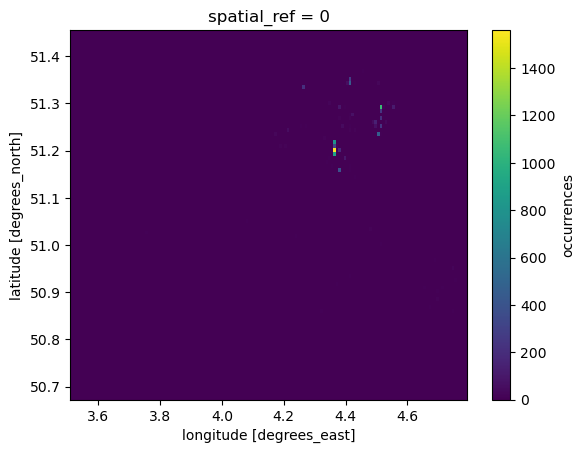

In [100]:
test_time["occurrences"].plot()

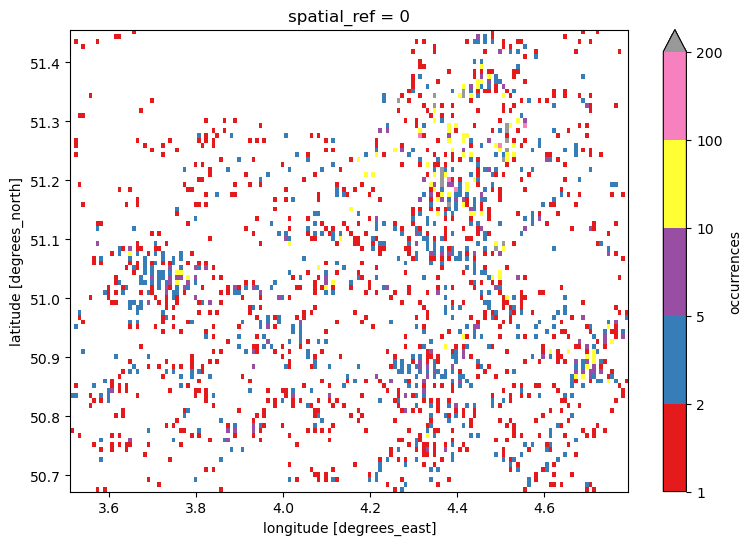

In [129]:
# 1. Mask the zeros (keep values only where > 0)
masked_map = test_time["occurrences"].where(test_time["occurrences"] > 0)

# 2. Plot using a nice sequential colormap (like 'viridis', 'plasma', or 'Reds')
masked_map.plot(
    cmap='Set1', 
    levels=[1,2,5,10,100,200], 
    size=6, 
    aspect=1.5
)

In [113]:
test_time["occurrences"].sum()

<xarray.DataArray 'occurrences' ()> Size: 8B
array(14992)
Coordinates:
    spatial_ref  int64 8B 0